# Laboratorio de regresión - 4

---
Nombre: **Alan Jesús Hernández Soto** \
Carrera: **Ingeniería Financiera** \
Materia: **Laboratorio de Aprendizaje Estadístico** \
Tipo de Trabajo: **Laboratorio**

---

## Modelos penalizados

Hasta ahora la función de costo que usamos para decidir qué tan bueno es nuestro modelo al momento de ajustar es:

$$ \text{RSS} = \sum_{i=1}^n e_i^2 = \sum_{i=1}^n (y_i - \hat{y_i})^2 $$

Dado que los errores obtenidos son una combinación de sesgo y varianza, puede ser que se sesgue un parámetro para minimizar el error. Esto significa que el modelo puede decidir que la salida no sea una combinación de los factores, sino una fuerte predilección sobre uno de los factores solamente. 

E.g. se quiere ajustar un modelo

$$ \hat{z} = \hat{\beta_0} + \hat{\beta_1} x + \hat{\beta_2} y $$

Se ajusta el modelo y se decide que la mejor decisión es $\hat{\beta_1} = 10000$ y $\hat{\beta_2}=50$. Considera limitaciones de problemas reales:
- Quizás los parámetros son ajustes de maquinaria que se deben realizar para conseguir el mejor producto posible, y que $10000$ sea imposible de asignar.
- Quizás los datos actuales están sesgados y sólo hacen parecer que uno de los factores importa más que el otro.

Una de las formas en las que se puede mitigar este problema es penalizando a los parámetros del modelo, cambiando la función de costo:

$$ \text{RSS}_{L2} = \sum_{i=1}^n e_i^2  + \lambda \sum_{j=1}^p \hat{\beta_j}^2 $$

El *L2* significa que se está agregando una penalización de segundo orden. Lo que hace esta penalización es que los factores ahora sólo tendrán permitido crecer si hay una reducción al menos proporcional en el error (sacrificamos sesgo, pero reducimos la varianza).

Asimismo, existe la penalización *L1*

$$ \text{RSS}_{L1} = \sum_{i=1}^n e_i^2  + \lambda \sum_{j=1}^p |\hat{\beta_j}| $$

A las penalizaciones *L2* y *L1* se les conoce también como Ridge y Lasso, respectivamente.

Para realizar una regresión con penalización de Ridge o de Lasso usamos el objeto `Ridge(alpha=?)` o `Lasso(alpha=?)` en lugar de `LinearRegression()` de `sklearn`.

Utiliza el dataset de publicidad (Advertising.csv), utiliza train-test-split de 70/30 y realiza 3 regresiones múltiples:

$$ \text{sales} = \beta_0 + \beta_1 (\text{TV}) + \beta_2 (\text{radio}) + \beta_3 (\text{newspaper}) + \epsilon $$

1. Sin penalización
2. Con penalización L2
3. Con penalización L1

¿Qué puedes observar al ajustar los valores de `alpha`? 

Compara los resultados de los coeficientes utilizando valores diferentes de $\alpha$ y los $R^2$ resultantes.



## Carga de Datos y Librerias

In [201]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

df = pd.read_csv('Datasets/Advertising.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)

X = df[['TV', 'radio', 'newspaper']].to_numpy()
Y = df['sales'].to_numpy()

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=12)
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


## Regresiones Múltiples

### 1. Sin Penalización

**sklearn**

In [202]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

y_pred = lr.predict(X_test)
RSS = np.sum((Y_test - y_pred) ** 2)
rm_sp = pd.DataFrame({
    'B0': lr.intercept_, 
    'B1': lr.coef_[0], 
    'B2': lr.coef_[1], 
    'B3': lr.coef_[2], 
    'RSS_test': RSS,
    'R2_test': lr.score(X_test, Y_test)}, index=[0])

rm_sp


,B0,B1,B2,B3,RSS_test,R2_test
0,2.8687,0.0451,0.195137,-0.003364,153.661656,0.913705


## 2. Con penalización L2

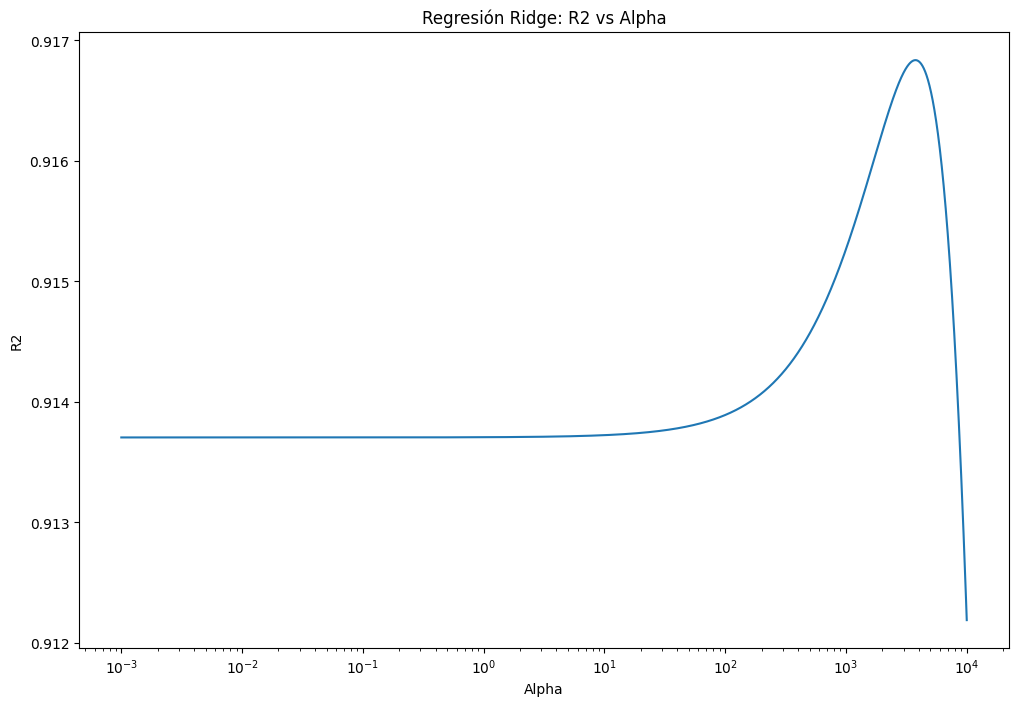

El valor de alpha que maximiza R2 es: 3758.8717292214346


In [203]:
R2 = []
B0 = []
B1 = []
B2 = []
B3 = []

alphas = np.logspace(-3, 4, 10000)
for i in range(len(alphas)):
    ridge = Ridge(alpha=alphas[i])
    ridge.fit(X_train, Y_train)
    R2.append(ridge.score(X_test, Y_test))
    B0.append(ridge.intercept_)
    B1.append(ridge.coef_[0])
    B2.append(ridge.coef_[1])
    B3.append(ridge.coef_[2])

plt.figure(figsize=(12, 8))
plt.plot(alphas, R2)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R2')
plt.title('Regresión Ridge: R2 vs Alpha')
plt.show()

rd = pd.DataFrame({'B0': B0,
                   'B1': B1,
                   'B2': B2,
                   'B3': B3,
                   'Alpha':alphas,
                   'R2':R2})
                   
max_alpha_rd = rd[rd['R2'] == rd['R2'].max()].values[:, 4]
print(f'El valor de alpha que maximiza R2 es: {max_alpha_rd[0]}')

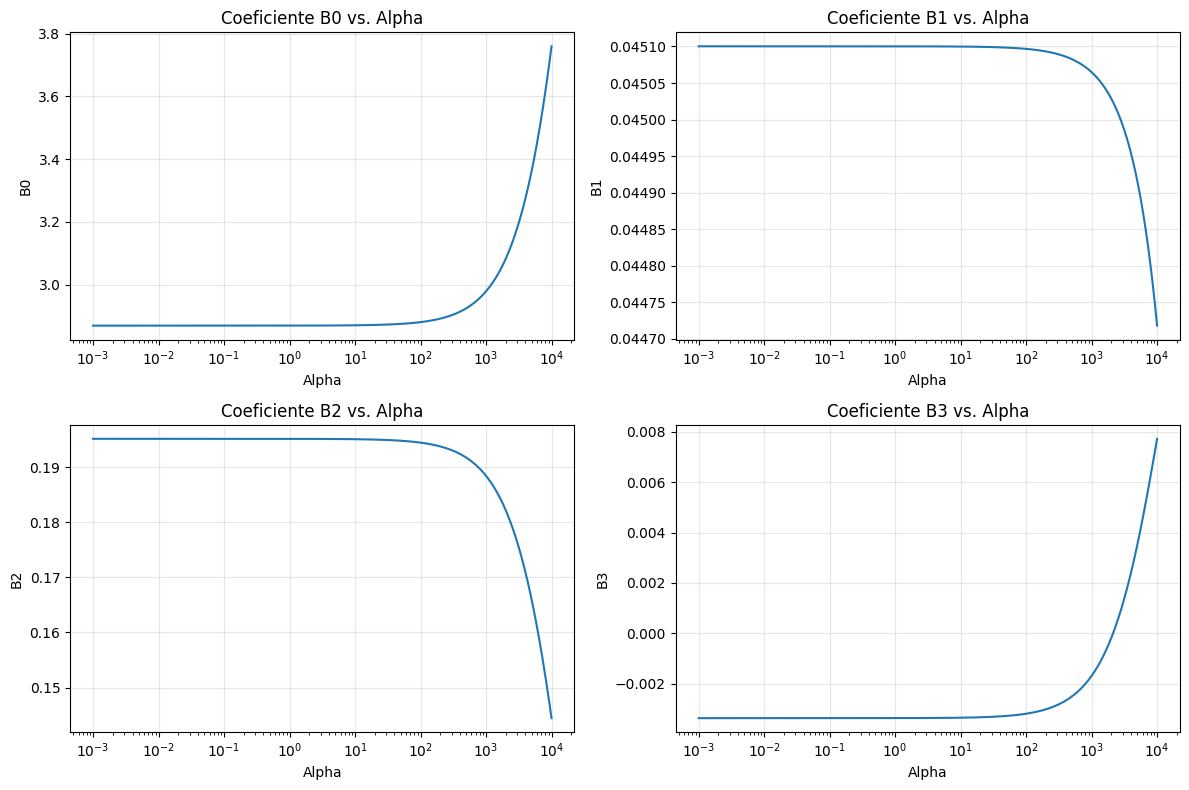

In [204]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(4):
    axes[i].plot(alphas, rd.iloc[:, i])
    axes[i].set_xscale('log')
    axes[i].set_xlabel('Alpha')
    axes[i].set_ylabel(f'B{i}')
    axes[i].set_title(f'Coeficiente B{i} vs. Alpha')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [205]:
ridge = Ridge(alpha=max_alpha_rd[0])
ridge.fit(X_train, Y_train)

rm_l2 = pd.DataFrame({
    'B0': ridge.intercept_,
    'B1': ridge.coef_[0],
    'B2': ridge.coef_[1],
    'B3': ridge.coef_[2],
    'Alpha': max_alpha_rd[0],
    'R2_test': ridge.score(X_test, Y_test)}, index=[0])
print('Coeficientes del Mejor Alpha Ridge:')
rm_l2

Coeficientes del Mejor Alpha Ridge:


,B0,B1,B2,B3,Alpha,R2_test
0,3.252688,0.044963,0.172195,0.002125,3758.871729,0.916836


## Con penalización L1

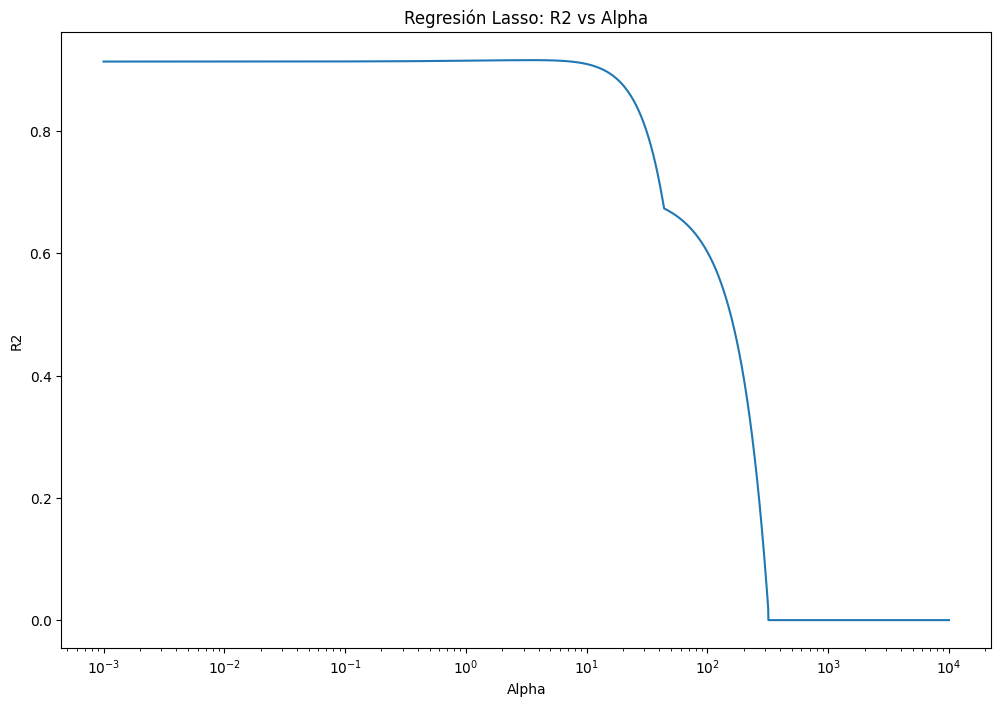

El valor de alpha que maximiza R2 es: 3.474994290813669


In [206]:
R2 = []
B0 = []
B1 = []
B2 = []
B3 = []

alphas = np.logspace(-3, 4, 10000)
for i in range(len(alphas)):
    lasso = Lasso(alpha=alphas[i])
    lasso.fit(X_train, Y_train)
    R2.append(lasso.score(X_test, Y_test))
    B0.append(lasso.intercept_)
    B1.append(lasso.coef_[0])
    B2.append(lasso.coef_[1])
    B3.append(lasso.coef_[2])

plt.figure(figsize=(12, 8))
plt.plot(alphas, R2)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R2')
plt.title('Regresión Lasso: R2 vs Alpha')
plt.show()

ls = pd.DataFrame({'B0': B0,
                   'B1': B1,
                   'B2': B2,
                   'B3': B3,
                   'Alpha':alphas,
                   'R2':R2})
max_alpha_ls = ls[ls['R2'] == ls['R2'].max()].values[:, 4]
print(f'El valor de alpha que maximiza R2 es: {max_alpha_ls[0]}')

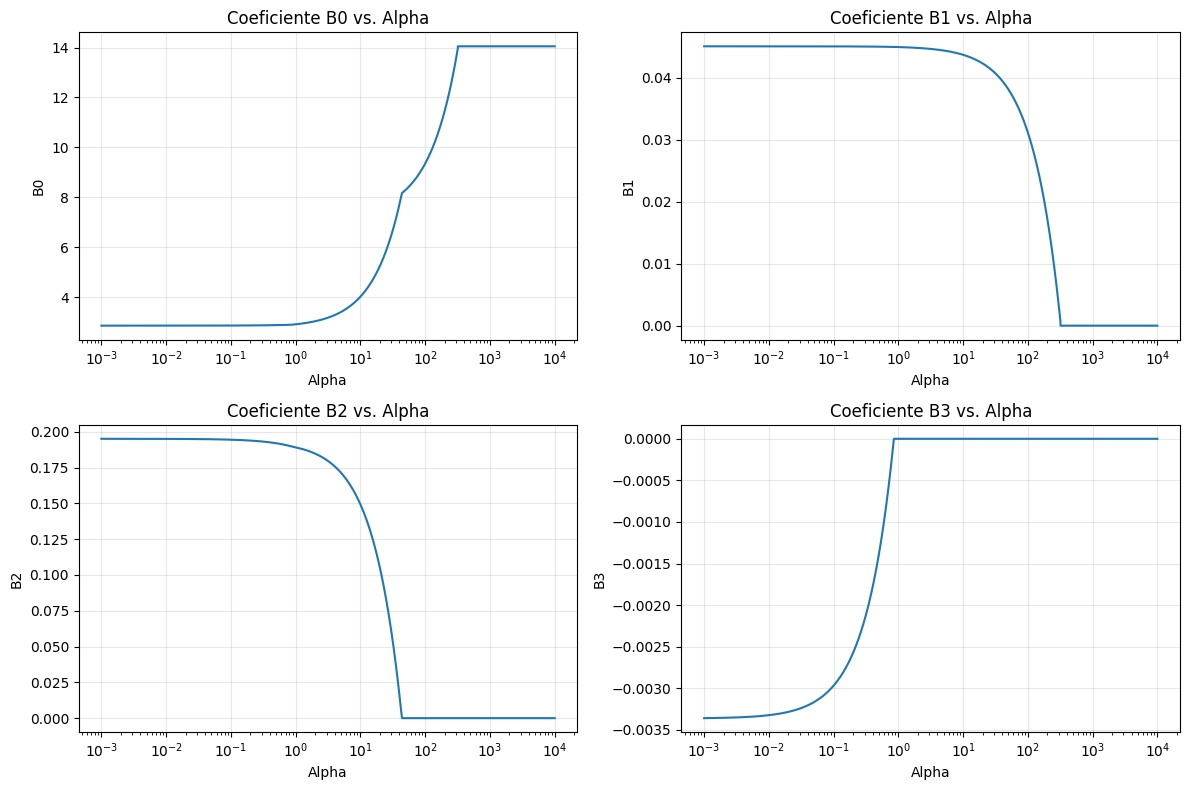

In [207]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(4):
    axes[i].plot(alphas, ls.iloc[:, i])
    axes[i].set_xscale('log')
    axes[i].set_xlabel('Alpha')
    axes[i].set_ylabel(f'B{i}')
    axes[i].set_title(f'Coeficiente B{i} vs. Alpha')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [208]:
lasso = Lasso(alpha=max_alpha_ls[0])
lasso.fit(X_train, Y_train)

rm_l1 = pd.DataFrame({
    'B0': lasso.intercept_,
    'B1': lasso.coef_[0],
    'B2': lasso.coef_[1],
    'B3': lasso.coef_[2],
    'Alpha': max_alpha_ls[0],
    'R2_test': lasso.score(X_test, Y_test)}, index=[0])
print('Coeficientes del Mejor Alpha Lasso:')
rm_l1

Coeficientes del Mejor Alpha Lasso:


,B0,B1,B2,B3,Alpha,R2_test
0,3.22685,0.044635,0.178235,0.0,3.474994,0.916056


# Resultados

### Observaciones
La regresion con mejor R2 fue la Ridge  (91.68%) con un Alpha aproximado de 3758.87 de allí le sigue Lasso con Alpha de 3.475 y 8 puntos base menos en score.

### Comparación de coeficientes y score
En el caso de Ridge los coeficientes a mayor alpha parece que divergen, y la R2 despues de un punto máximo se desploma a 0. Mientras que en Lasso a mayor alpha los coeficientes parecen converger en 0 o 14 en el caso de B0, mientras que la R2 parece mantenerse en un score constante por un momento y luego cae hasta 0.